In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# load data
admit = pd.read_csv('/content/drive/MyDrive/Bimbing/Regularized Regression in Python/regression_data.csv')
admit.head()

,gre_score,toefl_score,univ_ranking,motiv_letter_strength,recommendation_strength,gpa,research_exp,admit_prob
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
# split train test
from sklearn.model_selection import train_test_split

X = admit.drop(columns='admit_prob')
y = admit[['admit_prob']]
X.head(2)

,gre_score,toefl_score,univ_ranking,motiv_letter_strength,recommendation_strength,gpa,research_exp
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1


In [5]:
y.head(2)

,admit_prob
0,0.92
1,0.76


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train.shape, X_test.shape

((400, 7), (100, 7))

In [7]:
# calculate VIF scores
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

In [8]:
X = add_constant(X_train)
X

,const,gre_score,toefl_score,univ_ranking,motiv_letter_strength,recommendation_strength,gpa,research_exp
249,1.0,321,111,3,3.5,4.0,8.83,1
433,1.0,316,111,4,4.0,5.0,8.54,0
19,1.0,303,102,3,3.5,3.0,8.50,0
322,1.0,314,107,2,2.5,4.0,8.27,0
332,1.0,308,106,3,3.5,2.5,8.21,1
...,...,...,...,...,...,...,...,...
106,1.0,329,111,4,4.5,4.5,9.18,1
270,1.0,306,105,2,2.5,3.0,8.22,1
348,1.0,302,99,1,2.0,2.0,7.25,0
435,1.0,309,105,2,2.5,4.0,7.68,0


In [9]:
vif_df = pd.DataFrame([vif(X.values, i)
                      for i in range(X.shape[1])],
                      index=X.columns).reset_index()
vif_df

,index,0
0,const,1683.776580
1,gre_score,4.489983
2,toefl_score,3.664298
3,univ_ranking,2.572110
4,motiv_letter_strength,2.785764
5,recommendation_strength,1.977698
6,gpa,4.654540
7,research_exp,1.518065


In [11]:
vif_df.columns = ['feature','vif_score']
vif_df.head()

,feature,vif_score
0,const,1683.776580
1,gre_score,4.489983
2,toefl_score,3.664298
3,univ_ranking,2.572110
4,motiv_letter_strength,2.785764


In [14]:
vif_df = vif_df.loc[vif_df.feature!='const']
vif_df

,feature,vif_score
1,gre_score,4.489983
2,toefl_score,3.664298
3,univ_ranking,2.572110
4,motiv_letter_strength,2.785764
5,recommendation_strength,1.977698
6,gpa,4.654540
7,research_exp,1.518065


In [13]:
# y = b0 + b1*gre_score + b2*gpa
# parameter, coef, weight unreliable -> b0, b1, b2

In [17]:
admit_train = pd.concat([X_train, y_train], axis=1)
corr = admit_train.corr()
corr

,gre_score,toefl_score,univ_ranking,motiv_letter_strength,recommendation_strength,gpa,research_exp,admit_prob
gre_score,1.000000,0.817746,0.643475,0.617428,0.506241,0.824167,0.576955,0.820509
toefl_score,0.817746,1.000000,0.649494,0.645565,0.518661,0.797548,0.466876,0.789258
univ_ranking,0.643475,0.649494,1.000000,0.715971,0.597848,0.701813,0.435260,0.679056
motiv_letter_strength,0.617428,0.645565,0.715971,1.000000,0.654382,0.714200,0.396742,0.680343
recommendation_strength,0.506241,0.518661,0.597848,0.654382,1.000000,0.626748,0.327614,0.626950
gpa,0.824167,0.797548,0.701813,0.714200,0.626748,1.000000,0.493553,0.878106
research_exp,0.576955,0.466876,0.435260,0.396742,0.327614,0.493553,1.000000,0.544058
admit_prob,0.820509,0.789258,0.679056,0.680343,0.626950,0.878106,0.544058,1.000000


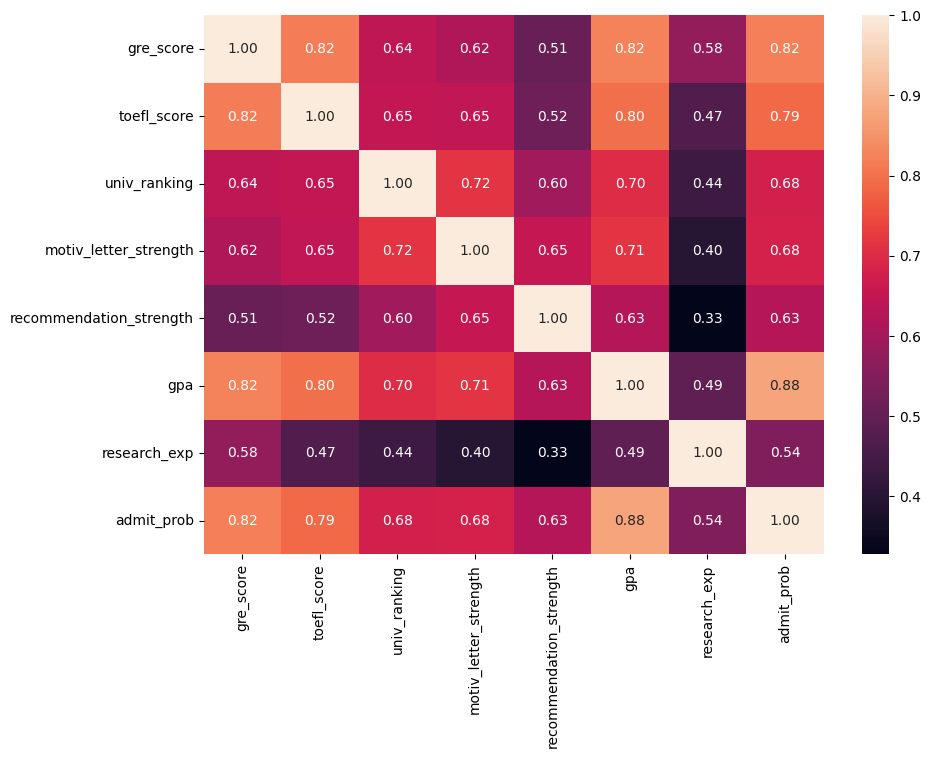

In [18]:
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()

In [19]:
# drop redundant features
X_train = X_train.drop(columns=['gre_score','toefl_score'])
X_test = X_test.drop(columns=['gre_score','toefl_score'])

In [20]:
X_train.head(2)

,univ_ranking,motiv_letter_strength,recommendation_strength,gpa,research_exp
249,3,3.5,4.0,8.83,1
433,4,4.0,5.0,8.54,0


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

X = add_constant(X_train)

vif_df = pd.DataFrame([vif(X.values, i)
               for i in range(X.shape[1])],
              index=X.columns).reset_index()
vif_df.columns = ['feature','vif_score']
vif_df = vif_df.loc[vif_df.feature!='const']
vif_df

,feature,vif_score
1,univ_ranking,2.511407
2,motiv_letter_strength,2.748278
3,recommendation_strength,1.965542
4,gpa,2.726281
5,research_exp,1.350514


In [24]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression

# train the model
X_admit_train = X_train.to_numpy()
y_admit_train = y_train.to_numpy()
y_admit_train = y_admit_train.reshape(len(y_admit_train),)

# define the model
ridge_reg = Ridge(alpha=0.1,
                  random_state=42)
ridge_reg.fit(X_admit_train, y_admit_train)

Ridge(alpha=0.1, random_state=42)

In [27]:
#  show as a nice dataframe

data = X_train
model = ridge_reg

coef_df = pd.DataFrame({
    'feature':['intercept'] + data.columns.tolist(),
    'coefficient':[model.intercept_] + list(model.coef_)
})

coef_df

,feature,coefficient
0,intercept,-0.764483
1,univ_ranking,0.007031
2,motiv_letter_strength,0.004406
3,recommendation_strength,0.014806
4,gpa,0.160723
5,research_exp,0.038290


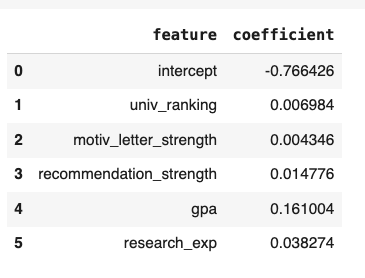

In [28]:
# from sklearn.linear_model import Lasso
# from sklearn.linear_model import Ridge
# from sklearn.linear_model import LinearRegression

from sklearn.linear_model import LinearRegression, Lasso, Ridge
# from sklearn.linear_model import *

In [29]:
# define the model
lasso_reg = Lasso(alpha=0.1,
                  random_state=42)

lasso_reg.fit(X_admit_train, y_admit_train)

Lasso(alpha=0.1, random_state=42)

In [31]:
# retrieve the coefficients
# show as a nice dataframe

data = X_train
model = lasso_reg

coef_df = pd.DataFrame({
    'feature':['intercept'] + data.columns.tolist(),
    'coefficient':[model.intercept_] + list(model.coef_)
})

coef_df

,feature,coefficient
0,intercept,0.702539
1,univ_ranking,0.006951
2,motiv_letter_strength,0.000000
3,recommendation_strength,0.000000
4,gpa,0.000000
5,research_exp,0.000000


## Workflow with choosing the best lambda

In [32]:
# split train test
from sklearn.model_selection import train_test_split

feature = admit.drop(columns='admit_prob')
target = admit[['admit_prob']]

In [ ]:
# 100 data
# 80 pre-train dan 20 test

# 60 train, 20 val dan 20 test

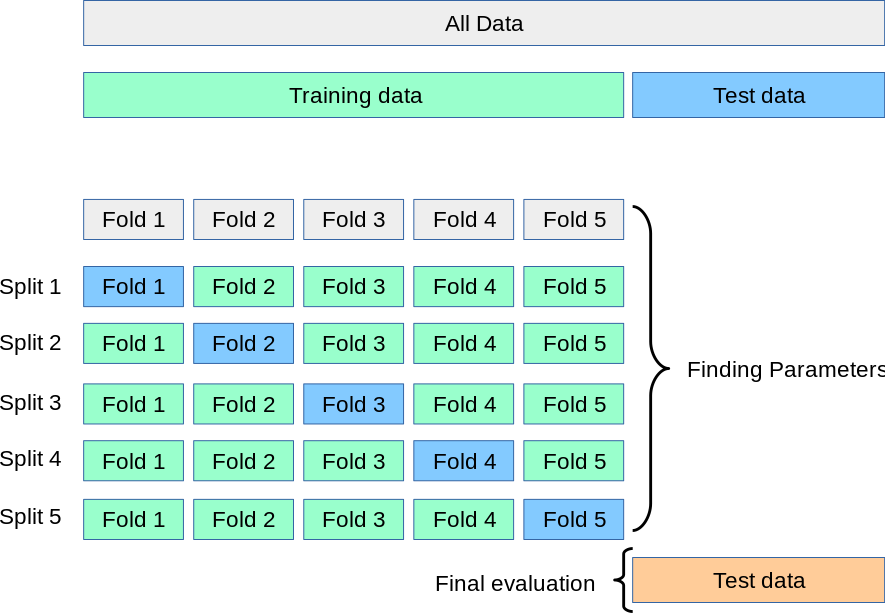

In [49]:
# First splitting: pretrain and test
X_pretrain, X_test, y_pretrain, y_test = train_test_split(feature, target, test_size=0.20, random_state=42)


# Second splitting: train and validation
X_train, X_validation, y_train, y_validation = train_test_split(X_pretrain, y_pretrain, test_size=0.20, random_state=42)

X_train.shape, X_test.shape, X_validation.shape

((320, 7), (100, 7), (80, 7))

In [56]:
# split train test
from sklearn.model_selection import train_test_split

feature = admit.drop(columns='admit_prob')
target = admit[['admit_prob']]

# First splitting: pretrain and test
feature_admit_pretrain, feature_admit_test, target_admit_pretrain, target_admit_test = train_test_split(feature, target, test_size=0.20, random_state=42)

# Second splitting: train and validation
feature_admit_train, feature_admit_validation, target_admit_train, target_admit_validation = train_test_split(feature_admit_pretrain, target_admit_pretrain, test_size=0.20, random_state=42)

In [34]:
X_train = X_train.drop(columns=['gre_score','toefl_score'])
X_validation = X_validation.drop(columns=['gre_score','toefl_score'])
X_test = X_test.drop(columns=['gre_score','toefl_score'])

In [57]:
feature_admit_train = feature_admit_train.drop(columns=['gre_score','toefl_score'])
feature_admit_validation = feature_admit_validation.drop(columns=['gre_score','toefl_score'])
feature_admit_test = feature_admit_test.drop(columns=['gre_score','toefl_score'])

In [35]:
X_train.head()

,univ_ranking,motiv_letter_strength,recommendation_strength,gpa,research_exp
322,2,2.5,4.0,8.27,0
117,4,2.0,2.5,7.46,0
311,4,4.5,4.0,9.18,1
254,4,4.0,5.0,9.12,0
288,4,5.0,5.0,9.02,0


In [39]:
# np.log(X_validation['gpa']+1)
# np.log(X_test['gpa']+1)

In [53]:
X_train.shape, X_test.shape, X_validation.shape

((320, 7), (100, 7), (80, 7))

In [58]:
from sklearn.linear_model import Ridge

# train the model
X_admit_train = feature_admit_train.to_numpy()
y_admit_train = target_admit_train.to_numpy()
y_admit_train = y_admit_train.reshape(len(y_admit_train),)

# define the model
# 4 models with 4 different alphas (lambda)
ridge_reg_pointzeroone = Ridge(alpha=0.01, random_state=42)
ridge_reg_pointone = Ridge(alpha=0.1, random_state=42)
ridge_reg_one = Ridge(alpha=1, random_state=42)
ridge_reg_ten = Ridge(alpha=10, random_state=42)

# fit the model (training)
ridge_reg_pointzeroone.fit(X_admit_train, y_admit_train)
ridge_reg_pointone.fit(X_admit_train, y_admit_train)
ridge_reg_one.fit(X_admit_train, y_admit_train)
ridge_reg_ten.fit(X_admit_train, y_admit_train)

Ridge(alpha=10, random_state=42)

In [54]:
# y_validation

In [59]:
from sklearn.metrics import mean_squared_error

X_admit_validation = feature_admit_validation.to_numpy()
y_admit_validation = target_admit_validation.to_numpy()
y_admit_validation = y_admit_validation.reshape(len(y_admit_validation),)

alphas = [0.01, 0.1, 1., 10]
models = [ridge_reg_pointzeroone,
          ridge_reg_pointone,
          ridge_reg_one,
          ridge_reg_ten]

for model, alpha in zip(models, alphas):
    y_predict_validation = model.predict(X_admit_validation)
    rmse = np.sqrt(mean_squared_error(y_admit_validation,y_predict_validation))
    print(f'RMSE of Ridge regression model with alpha = {alpha} is {rmse}')

RMSE of Ridge regression model with alpha = 0.01 is 0.05732468266149705
RMSE of Ridge regression model with alpha = 0.1 is 0.05734237964771404
RMSE of Ridge regression model with alpha = 1.0 is 0.057528698222295276
RMSE of Ridge regression model with alpha = 10 is 0.05983184011212863


In [60]:
ridge_best = ridge_reg_pointzeroone

coef_df = pd.DataFrame({
    'feature':['intercept'] + feature_admit_train.columns.tolist(),
    'coefficient':[ridge_best.intercept_] + list(ridge_best.coef_)
})

coef_df

,feature,coefficient
0,intercept,-0.741404
1,univ_ranking,0.005556
2,motiv_letter_strength,0.009497
3,recommendation_strength,0.015778
4,gpa,0.155693
5,research_exp,0.042721


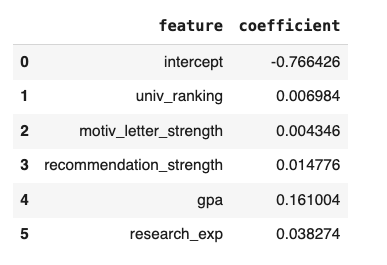

In [61]:
from sklearn.linear_model import Lasso

# train the model
X_admit_train = feature_admit_train.to_numpy()
y_admit_train = target_admit_train.to_numpy()
y_admit_train = y_admit_train.reshape(len(y_admit_train),)

# define the model
# 4 models with 4 different alphas (lambda)

# fit the model (training)


In [62]:
from sklearn.linear_model import Lasso

# train the model
X_admit_train = feature_admit_train.to_numpy()
y_admit_train = target_admit_train.to_numpy()
y_admit_train = y_admit_train.reshape(len(y_admit_train),)

# define the model
# 4 models with 4 different alphas (lambda)
lasso_reg_pointzeroone = Lasso(alpha=0.01, random_state=42)
lasso_reg_pointone = Lasso(alpha=0.1, random_state=42)
lasso_reg_one = Lasso(alpha=1, random_state=42)
lasso_reg_ten = Lasso(alpha=10, random_state=42)

# fit the model (training)
lasso_reg_pointzeroone.fit(X_admit_train, y_admit_train)
lasso_reg_pointone.fit(X_admit_train, y_admit_train)
lasso_reg_one.fit(X_admit_train, y_admit_train)
lasso_reg_ten.fit(X_admit_train, y_admit_train)

Lasso(alpha=10, random_state=42)

In [63]:
from sklearn.metrics import mean_squared_error

X_admit_validation = feature_admit_validation.to_numpy()
y_admit_validation = target_admit_validation.to_numpy()
y_admit_validation = y_admit_validation.reshape(len(y_admit_validation),)

alphas = [0.01, 0.1, 1., 10]
models = [lasso_reg_pointzeroone,
          lasso_reg_pointone,
          lasso_reg_one,
          lasso_reg_ten]

for model, alpha in zip(models, alphas):
    y_predict_validation = model.predict(X_admit_validation)
    rmse = np.sqrt(mean_squared_error(y_admit_validation,y_predict_validation))
    print(f'RMSE of Lasso regression model with alpha = {alpha} is {rmse}')

RMSE of Lasso regression model with alpha = 0.01 is 0.057615747182073775
RMSE of Lasso regression model with alpha = 0.1 is 0.11964923860775267
RMSE of Lasso regression model with alpha = 1.0 is 0.1263240539310012
RMSE of Lasso regression model with alpha = 10 is 0.1263240539310012


In [66]:
lasso_best = lasso_reg_pointzeroone

coef_df = pd.DataFrame({
    'feature':['intercept'] + feature_admit_train.columns.tolist(),
    'coefficient':[lasso_best.intercept_] + list(lasso_best.coef_)
})
coef_df

,feature,coefficient
0,intercept,-0.552726
1,univ_ranking,0.013259
2,motiv_letter_strength,0.011613
3,recommendation_strength,0.012677
4,gpa,0.133484
5,research_exp,0.008982


In [68]:
from sklearn.metrics import r2_score

y_predict_train = ridge_best.predict(X_admit_train)

print('R-squared for training data is {}'.format(r2_score(y_admit_train, y_predict_train)*100))

R-squared for training data is 79.83604440801396


In [70]:
# prepare prediction result on train data
y_predict_train = ridge_best.predict(X_admit_train)

In [71]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

print('RMSE for training data is {}'.format(np.sqrt(mean_squared_error(y_admit_train, y_predict_train))))
print('MAE for training data is {}'.format(mean_absolute_error(y_admit_train, y_predict_train)))
print('MAPE for training data is {}'.format(mean_absolute_percentage_error(y_admit_train, y_predict_train)))

RMSE for training data is 0.06452404616839902
MAE for training data is 0.04696727414428013
MAPE for training data is 0.0761569819236105


In [ ]:
# RMSE > MAE : ada prediksi yang outlier

In [72]:
# model kita hanya mampu memprediksi dengan tepat 79%

# mae : error 0.04 dari rata-rata 0.72
# ketika memprediksi ada error +- 0.04

In [73]:
admit[['admit_prob']].describe()

,admit_prob
count,500.00000
mean,0.72174
std,0.14114
min,0.34000
25%,0.63000
50%,0.72000
75%,0.82000
max,0.97000


In [ ]:
# mae : errro 300k dari rata2 harga motor 20jt
# ketika memprediksi harga motor maka ada error +- 300k

# mae : errro 300k dari rata2 harga product 1jt
# ketika memprediksi harga product maka ada error +- 300k

# mae : errro 300k dari rata2 harga mobil 300jt
# ketika memprediksi harga mobil maka ada error +- 300k